<a href="https://colab.research.google.com/github/JuchulShin/StudyAI/blob/1weeks/week1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 566kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.19MB/s]


60000
torch.Size([1, 28, 28]) 5


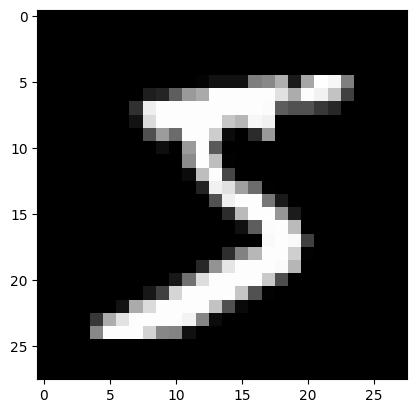

In [ ]:
from matplotlib import pyplot as plt


print(len(trainset))
print(trainset[0][0].shape, trainset[0][1])
plt.imshow(trainset[0][0][0], cmap='gray')

In [ ]:
batch_size = 64

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(images.shape, labels.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [ ]:
from torch import nn


class Model(nn.Module):
  def __init__(self, input_dim, n_dim):
    super().__init__()

    self.layer1 = nn.Linear(input_dim, n_dim)
    self.layer2 = nn.Linear(n_dim, n_dim)
    self.layer3 = nn.Linear(n_dim, 1)

    self.act = nn.ReLU()

  def forward(self, x):
    x = torch.flatten(x, start_dim=1)
    x = self.act(self.layer1(x))
    x = self.act(self.layer2(x))
    x = self.act(self.layer3(x))

    return x


model = Model(28 * 28 * 1, 1024)

In [ ]:
from torch.optim import SGD

lr = 0.001
model = model.to('cpu')

optimizer = SGD(model.parameters(), lr=lr)

In [ ]:
n_epochs = 100

for epoch in range(n_epochs):
  total_loss = 0.
  for data in trainloader:
    model.zero_grad()
    inputs, labels = data
    inputs, labels = inputs.to('cpu'), labels.to('cpu')

    preds = model(inputs)
    loss = (preds[:, 0] - labels).pow(2).mean()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch:3d} | Loss: {total_loss}")

Epoch   0 | Loss: 4614.768883228302
Epoch   1 | Loss: 2513.225419998169
Epoch   2 | Loss: 1809.9721561074257
Epoch   3 | Loss: 1426.8366839289665
Epoch   4 | Loss: 1206.0683688819408
Epoch   5 | Loss: 1067.246675491333
Epoch   6 | Loss: 966.4215855300426
Epoch   7 | Loss: 892.0939210951328
Epoch   8 | Loss: 828.5379579365253
Epoch   9 | Loss: 777.9769090116024
Epoch  10 | Loss: 733.5744847804308
Epoch  11 | Loss: 695.8470973968506
Epoch  12 | Loss: 661.2185735106468
Epoch  13 | Loss: 633.2455929517746
Epoch  14 | Loss: 604.9725335538387
Epoch  15 | Loss: 581.9426458626986
Epoch  16 | Loss: 560.2495635449886
Epoch  17 | Loss: 538.9374533593655
Epoch  18 | Loss: 517.0102212876081
Epoch  19 | Loss: 504.0847363322973
Epoch  20 | Loss: 484.29683442413807
Epoch  21 | Loss: 472.23675625026226
Epoch  22 | Loss: 456.2361164242029
Epoch  23 | Loss: 443.77526219189167
Epoch  24 | Loss: 429.203126847744
Epoch  25 | Loss: 418.52878415584564
Epoch  26 | Loss: 405.2602309882641
Epoch  27 | Loss: 396.

In [ ]:
idx = 0

x = trainset[idx][0][None]  # (1, 1, 28, 28)
x = x.to('cpu')

print(model(x))
print(trainset[idx][1])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

batch_size = 256
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
class Model(nn.Module):
  def __init__(self, input_dim, n_dim):
    super().__init__()

    self.layer1 = nn.Linear(input_dim, n_dim)
    self.layer2 = nn.Linear(n_dim, n_dim)
    self.layer3 = nn.Linear(n_dim, 10)

    self.act = nn.ReLU()

  def forward(self, x):
    x = torch.flatten(x, start_dim=1)
    x = self.act(self.layer1(x))
    x = self.act(self.layer2(x))
    x = self.layer3(x)

    return x

In [ ]:
model = Model(28 * 28 * 1, 1024)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
from torch.optim import SGD
from torch.nn import CrossEntropyLoss

# 학습률 설정
lr = 0.001
# 옵티마이저 설정
optimizer = SGD(model.parameters(), lr=lr)

# 손실 함수 설정 (CrossEntropyLoss)
criterion = CrossEntropyLoss()

In [ ]:
import numpy as np

# 정확도 측정 함수
def accuracy(model, dataloader):
  cnt = 0
  acc = 0

  model.eval()  # 평가 모드로 설정
  with torch.no_grad():  # 그래디언트 계산 비활성화
    for data in dataloader:
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)

      preds = model(inputs)
      preds = torch.argmax(preds, dim=-1)

      cnt += labels.shape[0]
      acc += (labels == preds).sum().item()

  return acc / cnt

# 정확도 시각화 함수
def plot_acc(train_accs, test_accs, label1='train', label2='test'):
  x = np.arange(len(train_accs))

  plt.figure(figsize=(10, 6))
  plt.plot(x, train_accs, label=label1)
  plt.plot(x, test_accs, label=label2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training and Test Accuracy over Epochs')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
# 학습 파라미터 설정
n_epochs = 100
batch_size = 256

# 학습 결과 저장용 리스트
train_accs = []
test_accs = []

# 학습 시작
for epoch in range(n_epochs):
  # 학습 모드
  model.train()
  total_loss = 0.0

  for data in trainloader:
    # 그래디언트 초기화
    optimizer.zero_grad()

    # 데이터 준비
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    # 순전파
    outputs = model(inputs)

    # 손실 계산
    loss = criterion(outputs, labels)

    # 역전파 및 가중치 업데이트
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  # 매 에폭마다 정확도 측정
  train_acc = accuracy(model, trainloader)
  test_acc = accuracy(model, testloader)

  # 정확도 저장
  train_accs.append(train_acc)
  test_accs.append(test_acc)

  # 진행 상황 출력
  print(f"Epoch {epoch+1:3d}/{n_epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# 학습 완료 메시지
print("학습 완료!")

In [ ]:
# 정확도 시각화
plot_acc(train_accs, test_accs)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
import numpy as np
from torch import nn
from torch.optim import SGD, Adam
from torch.nn import CrossEntropyLoss

# 데이터셋 로드
transform = transforms.ToTensor()

# CIFAR10 데이터셋 로드
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 데이터셋 크기 및 shape 확인
print(f"훈련 데이터셋 크기: {len(trainset)}")
print(f"입력 이미지 shape: {trainset[0][0].shape}, 레이블: {trainset[0][1]}")

# 이미지 시각화
plt.figure(figsize=(4, 4))
plt.imshow(trainset[0][0].permute(1, 2, 0))  # CIFAR10은 컬러 이미지이므로 채널 순서 변경
plt.title(f"Label: {trainset[0][1]}")
plt.show()

# 데이터로더 설정
batch_size = 256
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

# 배치 데이터 shape 확인
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(f"배치 이미지 shape: {images.shape}, 배치 레이블 shape: {labels.shape}")

In [ ]:
# 기본 모델 정의 (LeakyReLU 사용)
class Model(nn.Module):
    def __init__(self, input_dim, n_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, n_dim)
        self.layer2 = nn.Linear(n_dim, n_dim)
        self.layer3 = nn.Linear(n_dim, 10)  # CIFAR10은 10개 클래스

        self.act = nn.LeakyReLU(0.1)  # LeakyReLU 사용

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.layer3(x)  # 마지막 레이어는 활성화 함수 없음

        return x

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

In [ ]:
# 정확도 측정 함수
def accuracy(model, dataloader):
    cnt = 0
    acc = 0

    model.eval()  # 평가 모드로 설정
    with torch.no_grad():  # 그래디언트 계산 비활성화
        for data in dataloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            preds = model(inputs)
            preds = torch.argmax(preds, dim=-1)

            cnt += labels.shape[0]
            acc += (labels == preds).sum().item()

    return acc / cnt

# 정확도 시각화 함수
def plot_acc(accs_dict, title='Accuracy Comparison'):
    plt.figure(figsize=(10, 6))

    for label, accs in accs_dict.items():
        plt.plot(np.arange(len(accs)), accs, label=label)

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# 학습 함수 정의
def train_model(model, optimizer, n_epochs, trainloader, testloader, model_name="Model"):
    criterion = CrossEntropyLoss()
    train_accs = []

    print(f"Training {model_name}...")

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0

        for data in trainloader:
            optimizer.zero_grad()

            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # 매 에폭마다 정확도 측정
        train_acc = accuracy(model, trainloader)
        train_accs.append(train_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f}")

    return train_accs

# 모델 초기화 및 학습 (SGD)
n_epochs = 50
input_dim = 32 * 32 * 3  # CIFAR10 이미지 크기

model_sgd = Model(input_dim, 1024).to(device)
optimizer_sgd = SGD(model_sgd.parameters(), lr=0.001)
train_accs_sgd = train_model(model_sgd, optimizer_sgd, n_epochs, trainloader, testloader, "SGD Model")

# 모델 초기화 및 학습 (Adam)
model_adam = Model(input_dim, 1024).to(device)
optimizer_adam = Adam(model_adam.parameters(), lr=0.001)
train_accs_adam = train_model(model_adam, optimizer_adam, n_epochs, trainloader, testloader, "Adam Model")

# 결과 시각화 (Plot 1)
plot_acc({'SGD': train_accs_sgd, 'Adam': train_accs_adam}, 'SGD vs Adam - Training Accuracy')

In [ ]:
# Sigmoid를 사용하는 모델 정의
class ModelSigmoid(nn.Module):
    def __init__(self, input_dim, n_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, n_dim)
        self.layer2 = nn.Linear(n_dim, n_dim)
        self.layer3 = nn.Linear(n_dim, 10)

        self.act = nn.Sigmoid()  # Sigmoid 활성화 함수 사용

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.layer3(x)

        return x

# 모델 초기화 및 학습 (Sigmoid + Adam)
model_sigmoid = ModelSigmoid(input_dim, 1024).to(device)
optimizer_sigmoid = Adam(model_sigmoid.parameters(), lr=0.001)
train_accs_sigmoid = train_model(model_sigmoid, optimizer_sigmoid, n_epochs, trainloader, testloader, "Sigmoid Model")

# 결과 시각화 (Plot 2)
plot_acc({'LeakyReLU': train_accs_adam, 'Sigmoid': train_accs_sigmoid}, 'LeakyReLU vs Sigmoid - Training Accuracy')

In [ ]:
# Dropout을 적용한 모델 정의
class ModelDropout(nn.Module):
    def __init__(self, input_dim, n_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, n_dim)
        self.layer2 = nn.Linear(n_dim, n_dim)
        self.layer3 = nn.Linear(n_dim, 10)

        self.act = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(p=0.1)  # Dropout 확률 0.1

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(self.act(self.layer1(x)))
        x = self.dropout(self.act(self.layer2(x)))
        x = self.layer3(x)

        return x

# Dropout 모델 학습 함수
def train_model_with_dropout(model, optimizer, n_epochs, trainloader, testloader):
    criterion = CrossEntropyLoss()
    train_accs = []
    test_accs = []

    print("Training model with dropout...")

    for epoch in range(n_epochs):
        # 학습 모드
        model.train()
        total_loss = 0.0

        for data in trainloader:
            optimizer.zero_grad()

            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # 매 에폭마다 정확도 측정
        with torch.no_grad():
            model.eval()  # 평가 모드로 설정
            train_acc = accuracy(model, trainloader)
            test_acc = accuracy(model, testloader)

            train_accs.append(train_acc)
            test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return train_accs, test_accs

# 모델 초기화 및 학습 (Dropout + Adam)
model_dropout = ModelDropout(input_dim, 1024).to(device)
optimizer_dropout = Adam(model_dropout.parameters(), lr=0.001)
train_accs_dropout, test_accs_dropout = train_model_with_dropout(model_dropout, optimizer_dropout, n_epochs, trainloader, testloader)

# 결과 시각화 (Plot 3)
plot_acc({'Train': train_accs_dropout, 'Test': test_accs_dropout}, 'Train vs Test Accuracy with Dropout')

In [ ]:
# 모든 모델의 최종 정확도 비교
print("\n최종 훈련 정확도 비교:")
print(f"SGD + LeakyReLU: {train_accs_sgd[-1]:.4f}")
print(f"Adam + LeakyReLU: {train_accs_adam[-1]:.4f}")
print(f"Adam + Sigmoid: {train_accs_sigmoid[-1]:.4f}")
print(f"Adam + LeakyReLU + Dropout (Train): {train_accs_dropout[-1]:.4f}")
print(f"Adam + LeakyReLU + Dropout (Test): {test_accs_dropout[-1]:.4f}")

# 모든 모델의 훈련 정확도 비교 시각화
plot_acc({
    'SGD + LeakyReLU': train_accs_sgd,
    'Adam + LeakyReLU': train_accs_adam,
    'Adam + Sigmoid': train_accs_sigmoid,
    'Adam + LeakyReLU + Dropout': train_accs_dropout
}, 'Training Accuracy Comparison of All Models')